# Explainable Endometriosis Classification — CNN vs. Vision Transformer

Binary classification (endometriosis vs. normal) on a balanced, case-wise split of **GLENDA v1.5**, comparing **ResNet50**, **EfficientNet-B0** and **ViT-B/16**, plus quantitative Grad-CAM validation against expert lesion masks.

**Runtime:** Google Colab, T4 GPU.  
**Input:** `glenda_balanced.zip` produced by `scripts/prep_dataset.py` (upload it to the Colab session).

## 1. Data

In [3]:
!unzip -q glenda_balanced.zip -d data



## 2. Reproducibility, transforms and data loaders
ImageNet normalisation; light augmentation on train only. Positive class = `endometriosis`.

In [4]:
import torch, numpy as np, random, os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

IMG, BATCH = 224, 32
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG,IMG)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_tf = transforms.Compose([
    transforms.Resize((IMG,IMG)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

train_ds = datasets.ImageFolder("data/train", train_tf)
val_ds   = datasets.ImageFolder("data/val",   eval_tf)
test_ds  = datasets.ImageFolder("data/test",  eval_tf)
train_dl = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=2)

POS = train_ds.class_to_idx["endometriosis"]
print("class_to_idx:", train_ds.class_to_idx, "| POS:", POS)
print("Sizes -> train:",len(train_ds)," val:",len(val_ds)," test:",len(test_ds))

Device: cuda | GPU: Tesla T4
class_to_idx: {'endometriosis': 0, 'normal': 1} | POS: 0
Sizes -> train: 528  val: 111  test: 107


## 3. Training loop + ResNet50
Full fine-tuning with Adam, model selection and early stopping on **validation AUC** (patience 6).

In [5]:
import torch.nn as nn, copy
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score

def train_model(model, name, epochs=30, lr=1e-4, patience=6):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_auc, best_state, wait = 0.0, None, 0
    for ep in range(epochs):
        model.train()
        for x,y in train_dl:
            x,y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        model.eval(); probs, trues = [], []
        with torch.no_grad():
            for x,y in val_dl:
                p = torch.softmax(model(x.to(device)),1)[:,POS].cpu().numpy()
                probs += p.tolist(); trues += (y.numpy()==POS).astype(int).tolist()
        auc = roc_auc_score(trues, probs)
        f1  = f1_score(trues, [1 if p>=0.5 else 0 for p in probs])
        print(f"[{name}] epoch {ep+1:02d}  val_AUC={auc:.3f}  val_F1={f1:.3f}")
        if auc > best_auc: best_auc, best_state, wait = auc, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: print(f"  early stop @ epoch {ep+1}"); break
    model.load_state_dict(best_state)
    torch.save(best_state, f"best_{name}.pth")
    print(f"[{name}] BEST val AUC = {best_auc:.3f}  (saved best_{name}.pth)")
    return model

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = train_model(resnet, "resnet50")

[resnet50] epoch 01  val_AUC=0.714  val_F1=0.559
[resnet50] epoch 02  val_AUC=0.849  val_F1=0.745
[resnet50] epoch 03  val_AUC=0.939  val_F1=0.835
[resnet50] epoch 04  val_AUC=0.917  val_F1=0.828
[resnet50] epoch 05  val_AUC=0.906  val_F1=0.782
[resnet50] epoch 06  val_AUC=0.890  val_F1=0.767
[resnet50] epoch 07  val_AUC=0.938  val_F1=0.806
[resnet50] epoch 08  val_AUC=0.935  val_F1=0.794
[resnet50] epoch 09  val_AUC=0.936  val_F1=0.780
  early stop @ epoch 9
[resnet50] BEST val AUC = 0.939  (saved best_resnet50.pth)


## 4. EfficientNet-B0 and ViT-B/16

In [6]:
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 2)
effnet = train_model(effnet, "efficientnet_b0", lr=1e-4)

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2)
vit = train_model(vit, "vit_b16", lr=2e-5)

[efficientnet_b0] epoch 01  val_AUC=0.816  val_F1=0.717
[efficientnet_b0] epoch 02  val_AUC=0.871  val_F1=0.775
[efficientnet_b0] epoch 03  val_AUC=0.911  val_F1=0.811
[efficientnet_b0] epoch 04  val_AUC=0.929  val_F1=0.862
[efficientnet_b0] epoch 05  val_AUC=0.938  val_F1=0.850
[efficientnet_b0] epoch 06  val_AUC=0.939  val_F1=0.842
[efficientnet_b0] epoch 07  val_AUC=0.942  val_F1=0.838
[efficientnet_b0] epoch 08  val_AUC=0.956  val_F1=0.836
[efficientnet_b0] epoch 09  val_AUC=0.960  val_F1=0.855
[efficientnet_b0] epoch 10  val_AUC=0.959  val_F1=0.852
[efficientnet_b0] epoch 11  val_AUC=0.956  val_F1=0.847
[efficientnet_b0] epoch 12  val_AUC=0.949  val_F1=0.836
[efficientnet_b0] epoch 13  val_AUC=0.959  val_F1=0.837
[efficientnet_b0] epoch 14  val_AUC=0.953  val_F1=0.852
[efficientnet_b0] epoch 15  val_AUC=0.951  val_F1=0.855
  early stop @ epoch 15
[efficientnet_b0] BEST val AUC = 0.960  (saved best_efficientnet_b0.pth)


[vit_b16] epoch 01  val_AUC=0.890  val_F1=0.833
[vit_b16] epoch 02  val_AUC=0.968  val_F1=0.837
[vit_b16] epoch 03  val_AUC=0.973  val_F1=0.844
[vit_b16] epoch 04  val_AUC=0.965  val_F1=0.832
[vit_b16] epoch 05  val_AUC=0.950  val_F1=0.866
[vit_b16] epoch 06  val_AUC=0.955  val_F1=0.922
[vit_b16] epoch 07  val_AUC=0.958  val_F1=0.883
[vit_b16] epoch 08  val_AUC=0.961  val_F1=0.883
[vit_b16] epoch 09  val_AUC=0.962  val_F1=0.869
  early stop @ epoch 9
[vit_b16] BEST val AUC = 0.973  (saved best_vit_b16.pth)


## 5. Test-set evaluation
Accuracy, Precision, Recall, F1, ROC-AUC, ROC curves and confusion matrices on the held-out test set.

=== TEST-SET RESULTS ===
                 Accuracy  Precision  Recall      F1     AUC
ResNet50           0.8505     0.8033  0.9245  0.8596  0.9151
EfficientNet-B0    0.7290     0.6765  0.8679  0.7603  0.8326
ViT-B/16           0.7570     0.6800  0.9623  0.7969  0.8595


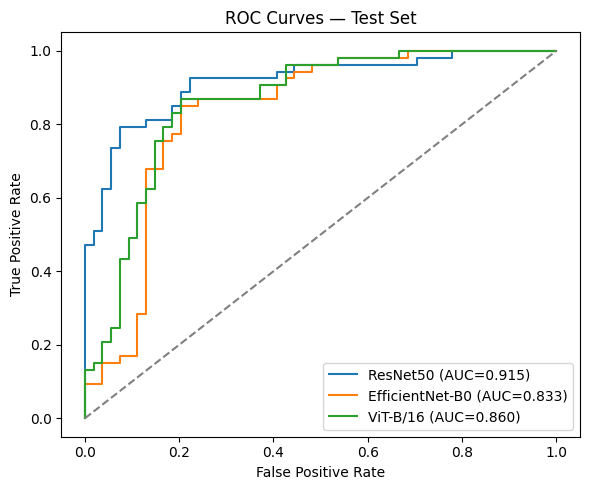

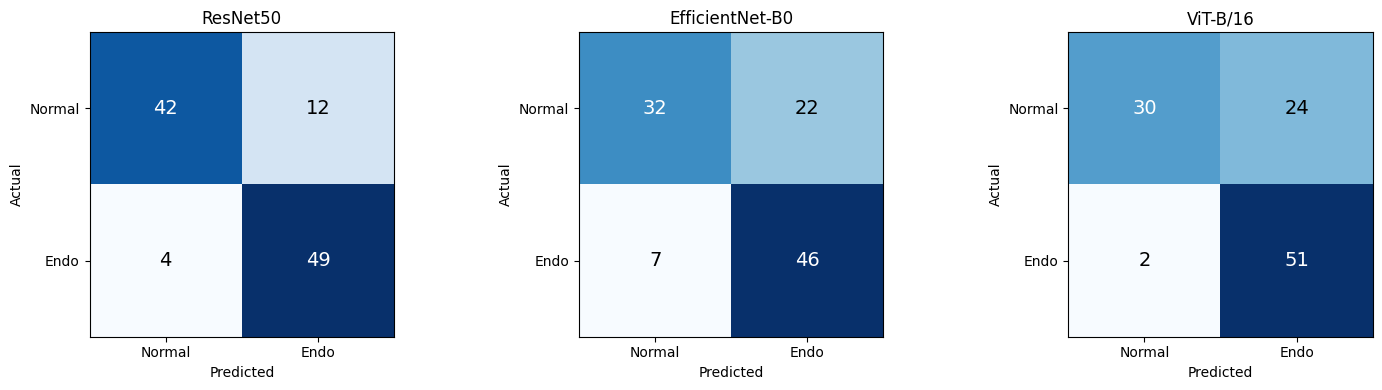

Done.


In [10]:
import matplotlib.pyplot as plt, pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

MODELS = {"ResNet50": resnet, "EfficientNet-B0": effnet, "ViT-B/16": vit}

def evaluate(model):
    model.eval(); probs, trues = [], []
    with torch.no_grad():
        for x,y in test_dl:
            p = torch.softmax(model(x.to(device)),1)[:,POS].cpu().numpy()
            probs += p.tolist(); trues += (y.numpy()==POS).astype(int).tolist()
    probs, trues = np.array(probs), np.array(trues); preds=(probs>=0.5).astype(int)
    return dict(Accuracy=accuracy_score(trues,preds), Precision=precision_score(trues,preds),
                Recall=recall_score(trues,preds), F1=f1_score(trues,preds),
                AUC=roc_auc_score(trues,probs)), trues, probs, preds

results, roc_data, cms = {}, {}, {}
for name, m in MODELS.items():
    metrics, trues, probs, preds = evaluate(m)
    results[name]=metrics; roc_data[name]=(trues,probs); cms[name]=confusion_matrix(trues,preds)

df = pd.DataFrame(results).T.round(4)
print("=== TEST-SET RESULTS ==="); print(df); df.to_csv("test_results.csv")

# --- ROC curves ---
plt.figure(figsize=(6,5))
for name,(t,p) in roc_data.items():
    fpr,tpr,_ = roc_curve(t,p); plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(t,p):.3f})")
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=200); plt.show()

# --- Confusion matrices (index 0 = Normal, 1 = Endo) ---
LABELS = ["Normal", "Endo"]
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,(name,cm) in zip(axes,cms.items()):
    ax.imshow(cm,cmap="Blues"); ax.set_title(name)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(LABELS); ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha="center",va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black",fontsize=14)
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=200); plt.show()
print("Done.")

## 6. Explainability — Grad-CAM vs. ground-truth lesion masks (IoU)
Heatmaps for the endometriosis class are binarised at 0.5 and compared with the GLENDA annotation masks.

In [11]:
!pip install -q grad-cam

import numpy as np, torch, os
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ViT needs a reshape (tokens -> feature map)
def vit_reshape(t, h=14, w=14):
    r = t[:, 1:, :].reshape(t.size(0), h, w, t.size(2))
    return r.transpose(2,3).transpose(1,2)

CAM_CFG = {
    "ResNet50":        (resnet, [resnet.layer4[-1]], None),
    "EfficientNet-B0": (effnet, [effnet.features[-1]], None),
    "ViT-B/16":        (vit,    [vit.encoder.layers[-1].ln_1], vit_reshape),
}

def preprocess(path):
    img = Image.open(path).convert("RGB").resize((224,224))
    arr = np.array(img)/255.0
    x = torch.tensor(arr).permute(2,0,1).float()
    x = (x - torch.tensor(MEAN).view(3,1,1)) / torch.tensor(STD).view(3,1,1)
    return x.unsqueeze(0), arr

def load_mask(path):
    m = np.array(Image.open(path).convert("L").resize((224,224)))
    return (m > 0).astype(np.uint8)     # binary lesion region

def iou(cam, mask, thr=0.5):
    pred = (cam >= thr).astype(np.uint8)
    inter = (pred & mask).sum(); union = (pred | mask).sum()
    return inter/union if union>0 else 0.0

IMG_DIR  = "data/test/endometriosis"
MASK_DIR = "data/masks/test/endometriosis"
files = [f for f in os.listdir(IMG_DIR) if os.path.exists(os.path.join(MASK_DIR, os.path.splitext(f)[0]+".png"))]
print("Test pathology images with mask:", len(files))

iou_results = {}
for name,(model,layers,reshape) in CAM_CFG.items():
    cam = GradCAM(model=model, target_layers=layers, reshape_transform=reshape)
    ious = []
    for f in files:
        x, _ = preprocess(os.path.join(IMG_DIR, f)); x = x.to(device)
        grayscale = cam(input_tensor=x, targets=[ClassifierOutputTarget(POS)])[0]
        mask = load_mask(os.path.join(MASK_DIR, os.path.splitext(f)[0]+".png"))
        ious.append(iou(grayscale, mask))
    iou_results[name] = (np.mean(ious), np.std(ious))
    print(f"{name:16s}  mean IoU = {np.mean(ious):.3f} ± {np.std(ious):.3f}")

import pandas as pd
pd.DataFrame({k:{"mean_IoU":v[0],"std":v[1]} for k,v in iou_results.items()}).T.round(4).to_csv("gradcam_iou.csv")
print("\nSaved gradcam_iou.csv")

Test pathology images with mask: 53
ResNet50          mean IoU = 0.148 ± 0.145
EfficientNet-B0   mean IoU = 0.238 ± 0.163
ViT-B/16          mean IoU = 0.032 ± 0.052
Saved gradcam_iou.csv


## 7. Pointing Game, Coverage and qualitative overlays
- **Pointing Game:** is the heatmap peak inside the lesion mask?
- **Coverage:** fraction of heatmap energy that falls inside the mask.

ResNet50          PointingGame=0.264  Coverage=0.165
EfficientNet-B0   PointingGame=0.453  Coverage=0.212
ViT-B/16          PointingGame=0.019  Coverage=0.069


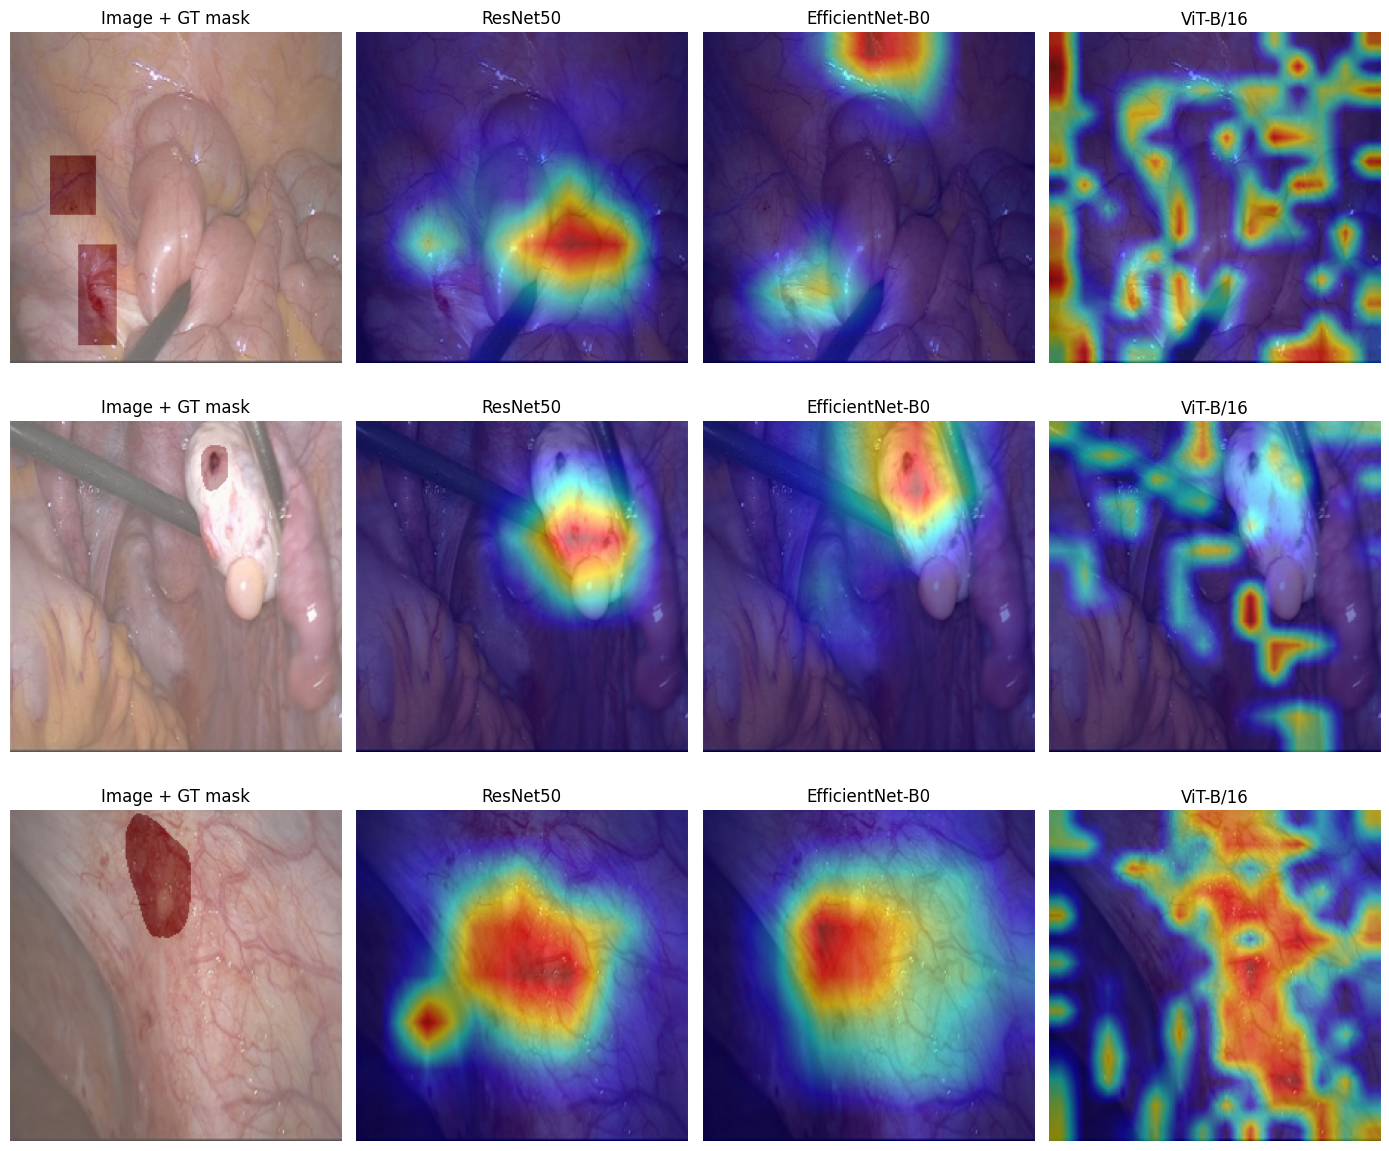

Saved localization metrics + overlays.


In [12]:
import matplotlib.pyplot as plt

def pointing_and_coverage(cam, mask):
    # Pointing game: is the CAM peak inside the mask?
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    hit = int(mask[peak] > 0)
    # Coverage: fraction of CAM energy inside the mask
    cov = (cam * mask).sum() / (cam.sum() + 1e-8)
    return hit, cov

loc_results = {}
for name,(model,layers,reshape) in CAM_CFG.items():
    cam = GradCAM(model=model, target_layers=layers, reshape_transform=reshape)
    hits, covs = [], []
    for f in files:
        x,_ = preprocess(os.path.join(IMG_DIR,f)); x=x.to(device)
        g = cam(input_tensor=x, targets=[ClassifierOutputTarget(POS)])[0]
        mask = load_mask(os.path.join(MASK_DIR, os.path.splitext(f)[0]+".png"))
        h,c = pointing_and_coverage(g, mask); hits.append(h); covs.append(c)
    loc_results[name] = (np.mean(hits), np.mean(covs))
    print(f"{name:16s}  PointingGame={np.mean(hits):.3f}  Coverage={np.mean(covs):.3f}")

import pandas as pd
pd.DataFrame({k:{"PointingGame":v[0],"Coverage":v[1]} for k,v in loc_results.items()}).T.round(4).to_csv("gradcam_localization.csv")

# --- Visual overlay: 3 example images, all 3 models ---
from pytorch_grad_cam.utils.image import show_cam_on_image
samples = files[:3]
fig, axes = plt.subplots(len(samples), 4, figsize=(14, 4*len(samples)))
for r,f in enumerate(samples):
    x, rgb = preprocess(os.path.join(IMG_DIR,f)); x=x.to(device)
    mask = load_mask(os.path.join(MASK_DIR, os.path.splitext(f)[0]+".png"))
    axes[r,0].imshow(rgb); axes[r,0].imshow(mask, alpha=0.35, cmap="Reds")
    axes[r,0].set_title("Image + GT mask"); axes[r,0].axis("off")
    for c,(name,(model,layers,reshape)) in enumerate(CAM_CFG.items(),1):
        cam = GradCAM(model=model, target_layers=layers, reshape_transform=reshape)
        g = cam(input_tensor=x, targets=[ClassifierOutputTarget(POS)])[0]
        axes[r,c].imshow(show_cam_on_image(rgb.astype(np.float32), g, use_rgb=True))
        axes[r,c].set_title(name); axes[r,c].axis("off")
plt.tight_layout(); plt.savefig("gradcam_overlays.png", dpi=200, bbox_inches="tight"); plt.show()
print("Saved localization metrics + overlays.")